# Setup

In [1]:
!pip install librosa tensorflow soundfile opendatasets

In [2]:
import os
import torch
import librosa
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import librosa.display
import opendatasets as od
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
od.download("https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio")

# Data Exploration

In [47]:
y, sr = librosa.load("/content/ravdess-emotional-speech-audio/Actor_01/03-01-01-01-01-01-01.wav")

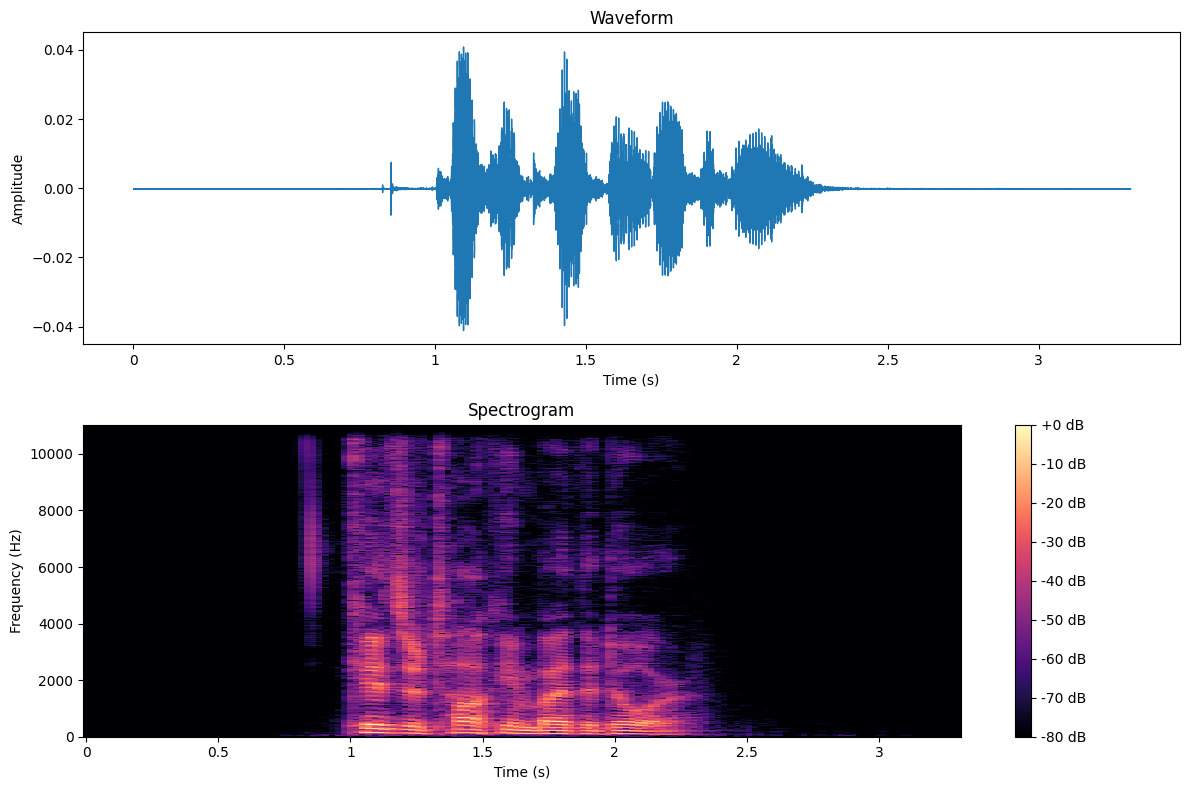

In [48]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
D = librosa.stft(y)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

In [6]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
print("MFCCs shape:", mfccs.shape)
print("First 5 MFCCs for the first coefficient:", mfccs[0, :5])

MFCCs shape: (40, 143)
First 5 MFCCs for the first coefficient: [-857.35706 -857.35706 -857.35706 -857.35706 -857.35706]


# Preprocessing

In [49]:
from torch.utils import data
dataset_path = "/content/ravdess-emotional-speech-audio"

paths = []
emotions = []

emotionDict = {
    "01": "neutral",
    "02": "calm" ,
    "03": "happy" ,
    "04": "sad" ,
    "05": "angry" ,
    "06": "fearful" ,
    "07": "disgust" ,
    "08": "surprised"
}

for root, dirs, files in os.walk(dataset_path):
  for file in files:
    if file.endswith(".wav"):
      emotionCode = file.split("-")[2]
      emotion = emotionDict[emotionCode]
      path = os.path.join(root, file)

      paths.append(path)
      emotions.append(emotion)

df = pd.DataFrame()
df["path"] = paths
df["emotion"] = emotions

df.head(10)

,path,emotion
0,/content/ravdess-emotional-speech-audio/Actor_...,happy
1,/content/ravdess-emotional-speech-audio/Actor_...,fearful
2,/content/ravdess-emotional-speech-audio/Actor_...,disgust
3,/content/ravdess-emotional-speech-audio/Actor_...,fearful
4,/content/ravdess-emotional-speech-audio/Actor_...,angry
5,/content/ravdess-emotional-speech-audio/Actor_...,surprised
6,/content/ravdess-emotional-speech-audio/Actor_...,sad
7,/content/ravdess-emotional-speech-audio/Actor_...,happy
8,/content/ravdess-emotional-speech-audio/Actor_...,angry
9,/content/ravdess-emotional-speech-audio/Actor_...,surprised


Text(0.5, 1.0, 'Emotion Distribution')

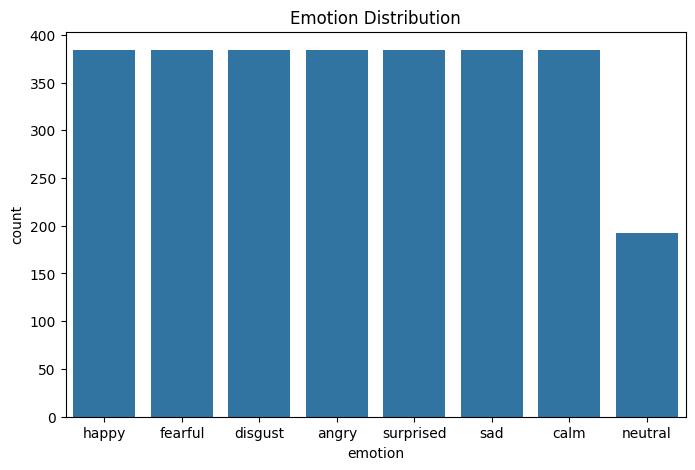

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")

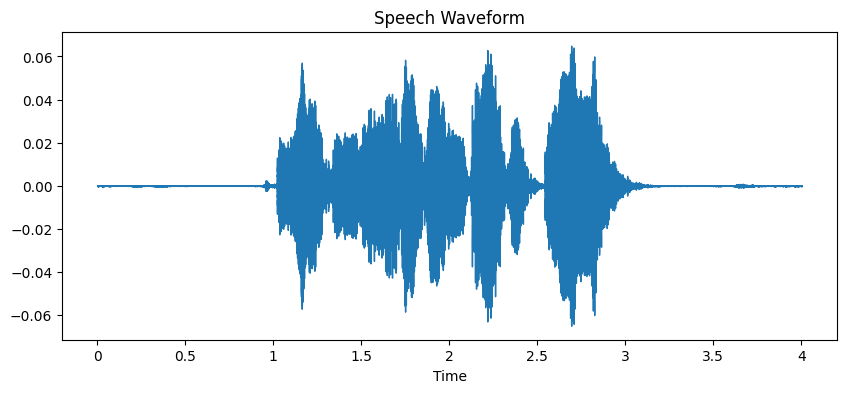

In [9]:
samplePath = df.path.iloc[0]
signal, sr = librosa.load(samplePath)

plt.figure(figsize=(10,4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Speech Waveform")
plt.show()

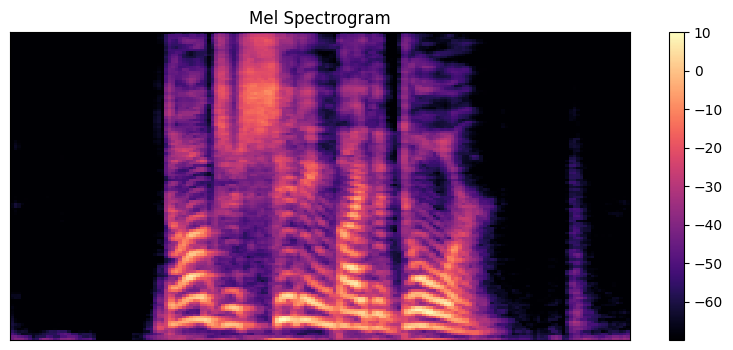

In [10]:
spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.power_to_db(spectrogram))
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

In [41]:
def extractFeatures(filePath):
    signal, sr = librosa.load(filePath, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)

    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)
    mel = librosa.feature.melspectrogram(y=signal, sr=sr)

    features = np.hstack([np.mean(mfcc.T, axis=0),
                          np.mean(chroma.T, axis=0),
                          np.mean(mel.T, axis=0)])
    return features

In [12]:
X = []
y = []

for path, emotion in zip(df.path, df.emotion):

    features = extractFeatures(path)

    X.append(features)
    y.append(emotion)

X = np.array(X)
y = np.array(y)

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = torch.tensor(X_train).float()
X_test = torch.tensor(X_test).float()

y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

# Model Building 1

In [ ]:
class EmotionLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):

        super(EmotionLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        output, (hn, cn) = self.lstm(x)

        out = self.fc(hn[-1])

        return out

In [ ]:
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model = EmotionLSTM(input_size, hidden_size, num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training 1

In [19]:
epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Early stopping parameters
best_val_loss = float('inf')
patience = 30
counter = 0

for epoch in range(epochs):

    # ======================
    # TRAINING
    # ======================
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training accuracy
    _, predicted = torch.max(outputs, 1)
    train_acc = (predicted == y_train).sum().item() / y_train.size(0)

    # ======================
    # VALIDATION
    # ======================
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

    # ======================
    # STORE VALUES
    # ======================
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ======================
    # EARLY STOPPING
    # ======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_lstm_ser_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

    # ======================
    # PRINT PROGRESS
    # ======================
    if (epoch+1) % 10 == 0 or epoch == 0:

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")
        print("--------------------------------------------------")

Epoch [1/100]
Train Loss: 2.0772 | Train Acc: 0.1480
Val   Loss: 2.0681 | Val   Acc: 0.1406
--------------------------------------------------
Epoch [10/100]
Train Loss: 2.0310 | Train Acc: 0.2483
Val   Loss: 2.0395 | Val   Acc: 0.2222
--------------------------------------------------
Epoch [20/100]
Train Loss: 1.9827 | Train Acc: 0.2821
Val   Loss: 1.9963 | Val   Acc: 0.2726
--------------------------------------------------
Epoch [30/100]
Train Loss: 1.9258 | Train Acc: 0.3043
Val   Loss: 1.9467 | Val   Acc: 0.2847
--------------------------------------------------
Epoch [40/100]
Train Loss: 1.8646 | Train Acc: 0.3247
Val   Loss: 1.8936 | Val   Acc: 0.3229
--------------------------------------------------
Epoch [50/100]
Train Loss: 1.8025 | Train Acc: 0.3494
Val   Loss: 1.8431 | Val   Acc: 0.3385
--------------------------------------------------
Epoch [60/100]
Train Loss: 1.7443 | Train Acc: 0.3845
Val   Loss: 1.7929 | Val   Acc: 0.3438
--------------------------------------------

# Evaluation 1

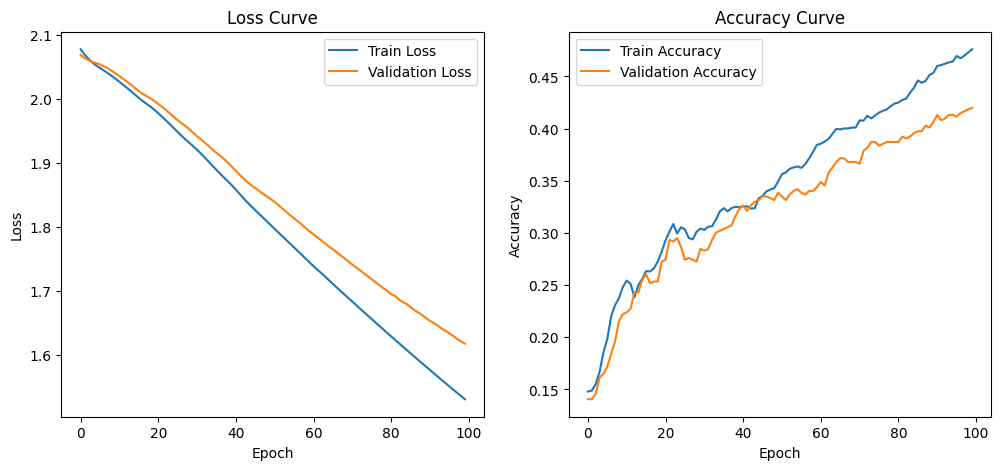

In [20]:
plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [21]:
with torch.no_grad():

    predictions = model(X_test)

    predicted = torch.argmax(predictions, axis=1)

In [23]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.69      0.64      0.67        87
           1       0.33      0.77      0.47        74
           2       0.48      0.37      0.42        78
           3       0.36      0.43      0.39        63
           4       0.51      0.33      0.40        78
           5       0.00      0.00      0.00        44
           6       0.38      0.18      0.24        84
           7       0.33      0.47      0.39        68

    accuracy                           0.42       576
   macro avg       0.39      0.40      0.37       576
weighted avg       0.41      0.42      0.40       576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


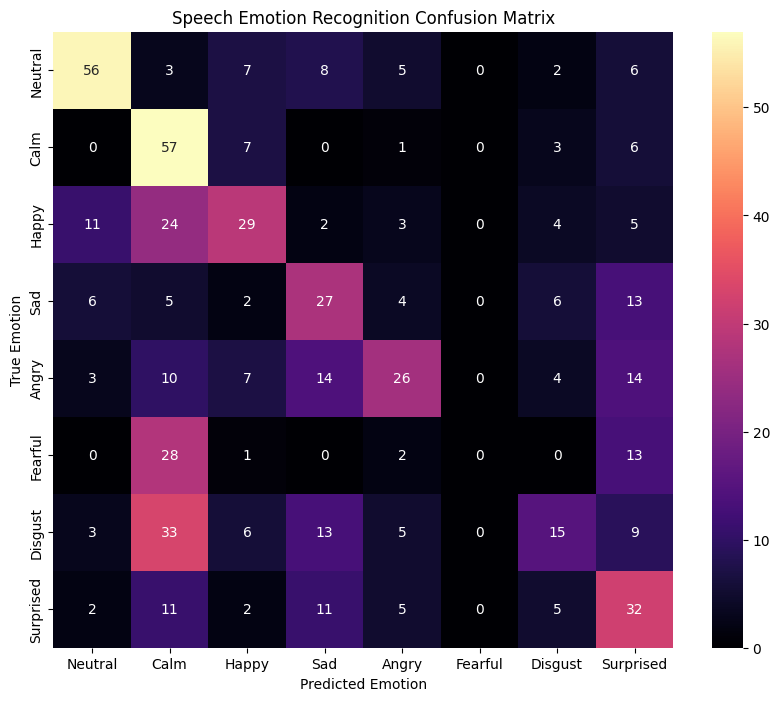

In [25]:
# Create confusion matrix
cm = confusion_matrix(y_test, predicted)

labels = ['Neutral','Calm','Happy','Sad','Angry','Fearful','Disgust','Surprised']

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='magma')

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Speech Emotion Recognition Confusion Matrix")

plt.show()

# Model Building 2

In [26]:
class EmotionBiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(EmotionBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):

        x = x.unsqueeze(1)

        output, (hn, cn) = self.lstm(x)

        out = self.fc(output[:, -1, :])

        return out

In [27]:
input_size = X_train.shape[1]
hidden_size = 128
num_classes = len(np.unique(y))

model_bilstm = EmotionBiLSTM(input_size, hidden_size, num_classes)

In [43]:
class CNN_BiLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(CNN_BiLSTM, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_size*2, num_classes)
        self.dropout_final = nn.Dropout(0.3)

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = x.permute(0,2,1)

        output, _ = self.lstm(x)

        out = self.dropout_final(output[:, -1, :])
        out = self.fc(output[:, -1, :])

        return out

In [30]:
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

# Training 2

In [31]:
def train_model(model, model_name, X_train, y_train, X_test, y_test,
                criterion, optimizer, epochs=100, patience=30):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):

        # ======================
        # TRAINING
        # ======================
        model.train()

        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Training accuracy
        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).sum().item() / y_train.size(0)

        # ======================
        # VALIDATION
        # ======================
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_test)
            val_loss = criterion(val_outputs, y_test)

            _, val_predicted = torch.max(val_outputs, 1)
            val_acc = (val_predicted == y_test).sum().item() / y_test.size(0)

        # ======================
        # STORE VALUES
        # ======================
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # ======================
        # EARLY STOPPING
        # ======================
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            counter = 0

            torch.save(model.state_dict(), f"best_{model_name}.pth")

        else:
            counter += 1

        if counter >= patience:

            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # ======================
        # PRINT PROGRESS
        # ======================
        if (epoch+1) % 10 == 0 or epoch == 0:

            print(f"{model_name} Epoch [{epoch+1}/{epochs}]")

            print(f"Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
            print(f"Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")

            print("--------------------------------------------------")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [32]:
model_bilstm = EmotionBiLSTM(input_size, 128, num_classes)

optimizer_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=0.01)

train_losses_bi, val_losses_bi, train_acc_bi, val_acc_bi = train_model(
    model_bilstm,
    "bilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_bilstm
)

bilstm Epoch [1/100]
Train Loss: 2.0769 | Train Acc: 0.1345
Val   Loss: 2.0831 | Val   Acc: 0.1111
--------------------------------------------------
bilstm Epoch [10/100]
Train Loss: 1.8271 | Train Acc: 0.3147
Val   Loss: 1.8595 | Val   Acc: 0.2587
--------------------------------------------------
bilstm Epoch [20/100]
Train Loss: 1.7384 | Train Acc: 0.3550
Val   Loss: 1.8501 | Val   Acc: 0.3247
--------------------------------------------------
bilstm Epoch [30/100]
Train Loss: 1.4572 | Train Acc: 0.4553
Val   Loss: 1.4952 | Val   Acc: 0.4323
--------------------------------------------------
bilstm Epoch [40/100]
Train Loss: 1.2852 | Train Acc: 0.4991
Val   Loss: 1.4224 | Val   Acc: 0.4583
--------------------------------------------------
bilstm Epoch [50/100]
Train Loss: 1.0477 | Train Acc: 0.6168
Val   Loss: 1.2202 | Val   Acc: 0.5330
--------------------------------------------------
bilstm Epoch [60/100]
Train Loss: 0.9290 | Train Acc: 0.6684
Val   Loss: 1.1109 | Val   Acc: 0.

In [33]:
model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)

optimizer_cnn = torch.optim.Adam(model_cnnbilstm.parameters(), lr=0.004)

train_losses_cnn, val_losses_cnn, train_acc_cnn, val_acc_cnn = train_model(
    model_cnnbilstm,
    "cnnbilstm",
    X_train, y_train,
    X_test, y_test,
    criterion,
    optimizer_cnn
)

cnnbilstm Epoch [1/100]
Train Loss: 2.0774 | Train Acc: 0.1263
Val   Loss: 2.0580 | Val   Acc: 0.1424
--------------------------------------------------
cnnbilstm Epoch [10/100]
Train Loss: 1.8874 | Train Acc: 0.2795
Val   Loss: 1.9326 | Val   Acc: 0.2500
--------------------------------------------------
cnnbilstm Epoch [20/100]
Train Loss: 1.6967 | Train Acc: 0.3524
Val   Loss: 1.7954 | Val   Acc: 0.2899
--------------------------------------------------
cnnbilstm Epoch [30/100]
Train Loss: 1.5743 | Train Acc: 0.3945
Val   Loss: 1.6812 | Val   Acc: 0.3611
--------------------------------------------------
cnnbilstm Epoch [40/100]
Train Loss: 1.3986 | Train Acc: 0.4740
Val   Loss: 1.6137 | Val   Acc: 0.4028
--------------------------------------------------
cnnbilstm Epoch [50/100]
Train Loss: 1.1821 | Train Acc: 0.5694
Val   Loss: 1.4520 | Val   Acc: 0.4913
--------------------------------------------------
cnnbilstm Epoch [60/100]
Train Loss: 0.9049 | Train Acc: 0.6740
Val   Loss: 1

# Evaluation 2

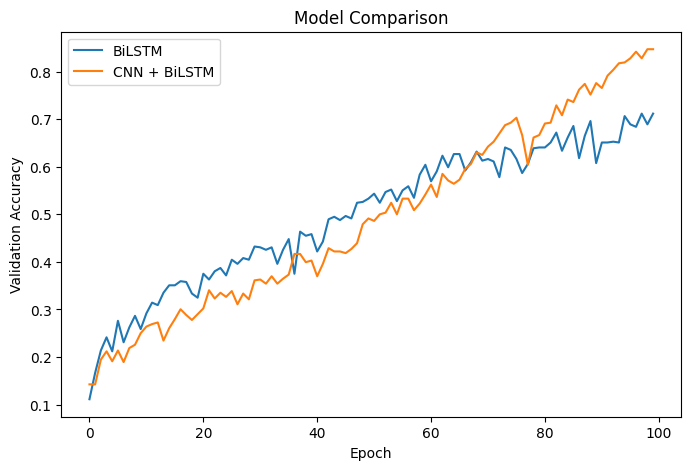

In [34]:
plt.figure(figsize=(8,5))

plt.plot(val_acc_bi, label="BiLSTM")
plt.plot(val_acc_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.legend()

plt.show()

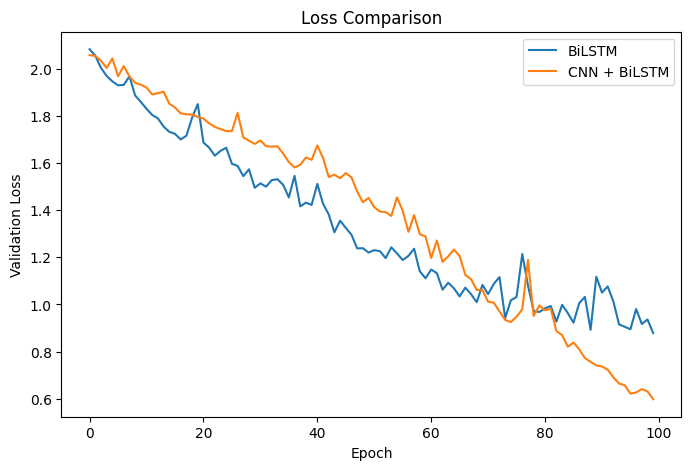

In [35]:
plt.figure(figsize=(8,5))

plt.plot(val_losses_bi, label="BiLSTM")
plt.plot(val_losses_cnn, label="CNN + BiLSTM")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss Comparison")

plt.legend()

In [37]:
# BiLSTM Predictions
model_bilstm.eval()

with torch.no_grad():
    outputs_bi = model_bilstm(X_test)
    _, preds_bi = torch.max(outputs_bi, 1)


# CNN + BiLSTM Predictions
model_cnnbilstm.eval()

with torch.no_grad():
    outputs_cnn = model_cnnbilstm(X_test)
    _, preds_cnn = torch.max(outputs_cnn, 1)

In [38]:
from sklearn.metrics import confusion_matrix

cm_bi = confusion_matrix(y_test, preds_bi)
cm_cnn = confusion_matrix(y_test, preds_cnn)

In [39]:
emotion_labels = [
    "Neutral",
    "Calm",
    "Happy",
    "Sad",
    "Angry",
    "Fearful",
    "Disgust",
    "Surprised"
]

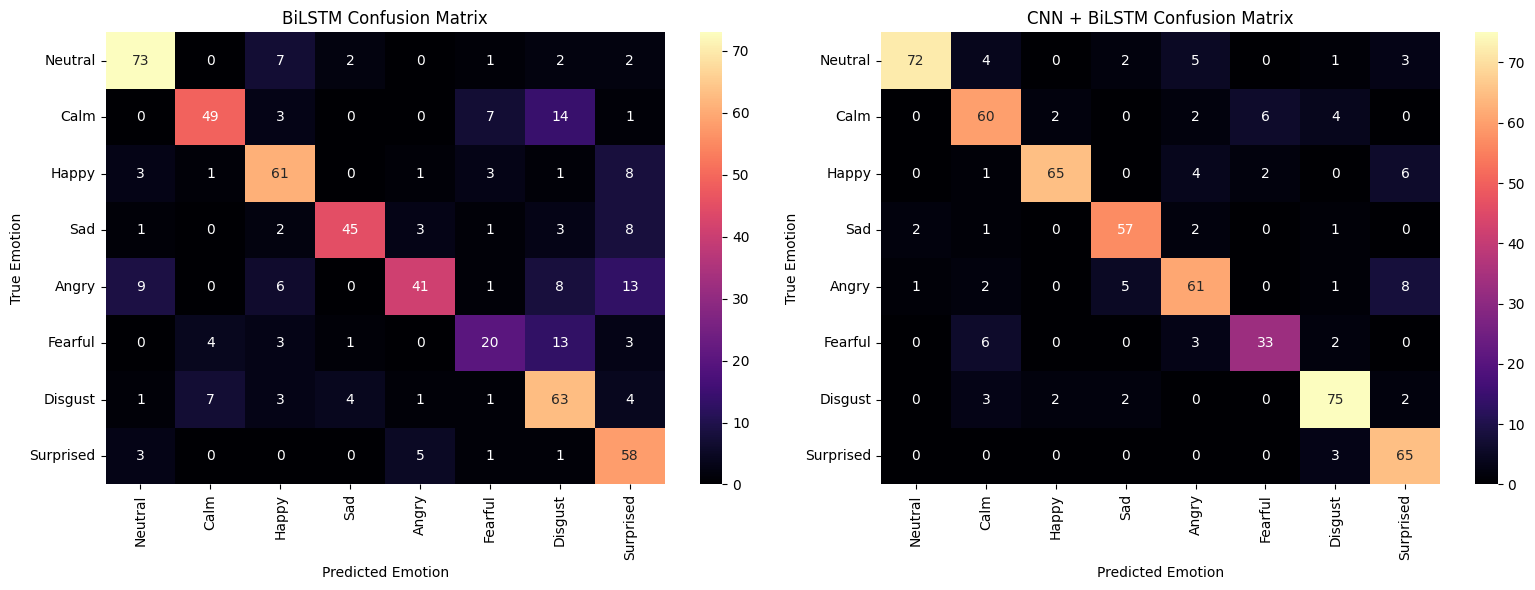

In [40]:
plt.figure(figsize=(16,6))

# BiLSTM Heatmap
plt.subplot(1,2,1)

sns.heatmap(cm_bi,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")


# CNN + BiLSTM Heatmap
plt.subplot(1,2,2)

sns.heatmap(cm_cnn,
            annot=True,
            fmt="d",
            cmap="magma",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)

plt.title("CNN + BiLSTM Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.tight_layout()
plt.show()